## AGN Homework 4 – Black Hole Mass & Accretion Disk Parameters Estimation

#### Preamble Definition

In [1]:
%matplotlib inline
%config InlineBackend.figure_formats = ['svg']

import pandas as pd
import numpy as np
import matplotlib as mpl

import matplotlib.pyplot as plt

plt.rcParams['figure.constrained_layout.use'] = True
plt.rcParams['legend.frameon'] = False
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True
plt.rcParams['axes.formatter.use_mathtext'] = True

#### Helper Functions

In [2]:
def gen_corner(df, x_param, y_param, x_label=None, y_label=None, bins=25, cmap='Blues', xscale='linear', yscale='linear'):
    valid_data = df[[x_param, y_param]].dropna()
    
    if xscale == 'log':
        valid_data = valid_data[valid_data[x_param] > 0]
    if yscale == 'log':
        valid_data = valid_data[valid_data[y_param] > 0]
        
    if xscale == 'log':
        xbins = np.logspace(np.log10(valid_data[x_param].min()), np.log10(valid_data[x_param].max()), bins + 1)
    else:
        xbins = np.linspace(valid_data[x_param].min(), valid_data[x_param].max(), bins + 1)
        
    if yscale == 'log':
        ybins = np.logspace(np.log10(valid_data[y_param].min()), np.log10(valid_data[y_param].max()), bins + 1)
    else:
        ybins = np.linspace(valid_data[y_param].min(), valid_data[y_param].max(), bins + 1)

    fig, axes = plt.subplots(2, 2, figsize=(6, 6), sharex='col', sharey='row')
    
    ax_histx = axes[0, 0]
    ax_hide  = axes[0, 1]
    ax_2d    = axes[1, 0]
    ax_histy = axes[1, 1]
    
    ax_hide.set_visible(False)
    ax_hide.set_in_layout(False)

    if xscale == 'log':
        ax_2d.set_xscale('log')
    if yscale == 'log':
        ax_2d.set_yscale('log')
    
    ax_histx.hist(valid_data[x_param], bins=xbins, color='gainsboro', edgecolor='dimgray', linewidth=0.8)
    ax_histx.set_ylabel(r'$N$')
    ax_histx.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
    
    ax_2d.hist2d(valid_data[x_param], valid_data[y_param], bins=[xbins, ybins], cmap=cmap, cmin=1)
    ax_2d.set_xlabel(x_label if x_label else x_param, fontsize=11)
    ax_2d.set_ylabel(y_label if y_label else y_param, fontsize=11)
    
    ax_histy.hist(valid_data[y_param], bins=ybins, orientation='horizontal', color='gainsboro', edgecolor='dimgray', linewidth=0.8)
    ax_histy.set_xlabel(r'$N$')
    ax_histy.tick_params(axis='y', which='both', left=False, labelleft=False)
        
    return fig, axes

### 1. Reverberation Mapping Scaling Relations

#### a)

In [3]:
sample = pd.read_csv('sample.csv')
display(sample.head(11))
print(f'\nSampled Data Frame Length: {len(sample)}\n')

,RAJ2000,DEJ2000,Plate,Fiber,MJD,iMAG,logLbol,e_logLbol,logLBHb,e_logLBHb,W_BHb_,e_W_BHb_,EWBHb,e_EWBHb,SN_Hb_,logBH,e_logBH,logEdd
0,189.67804,45.30687,1372,486,53062,-23.20,45.236,0.004,42.35,0.02,4399.3,330.1,62.0,3.10,23.06,8.33,0.07,-1.20
1,189.77188,41.44564,1984,609,53433,-22.29,44.819,0.005,42.11,0.04,2371.4,541.6,89.4,8.70,15.06,7.59,0.20,-0.87
2,189.81419,53.23740,885,449,52379,-22.69,45.121,0.004,41.93,0.04,10756.6,4366.4,32.1,3.40,16.27,9.05,0.35,-2.03
3,189.93733,19.90707,2614,350,54481,-23.37,45.132,0.001,42.55,0.02,15241.3,362.8,118.7,6.30,19.79,9.36,0.02,-2.33
4,189.99405,49.09448,1278,96,52735,-22.77,45.166,0.011,42.25,0.01,1385.6,48.6,52.5,2.90,15.96,7.29,0.03,-0.23
5,190.05440,31.04537,2237,448,53828,-22.70,45.098,0.005,41.54,0.08,4940.4,2527.9,13.2,3.20,17.40,8.36,0.44,-1.37
6,190.40521,44.74830,1372,589,53062,-22.45,45.066,0.002,41.42,0.03,1506.3,110.8,10.2,0.67,18.00,7.32,0.06,-0.35
7,190.59734,19.78912,2614,279,54481,-22.90,45.099,0.002,42.30,0.02,4480.9,176.4,72.2,3.10,27.18,8.28,0.03,-1.28
8,190.65991,4.93792,846,119,52407,-22.70,45.035,0.004,42.32,0.03,6825.3,345.0,87.4,6.00,17.87,8.61,0.04,-1.68
9,190.84929,5.24622,846,596,52407,-23.07,45.189,0.002,42.41,0.02,3693.9,232.3,77.8,3.10,29.46,8.16,0.05,-1.07



Sampled Data Frame Length: 500



#### Data Preparation

In [4]:
def cleans(df):
    clean = df[['Plate', 'MJD', 'Fiber']].copy()
    clean.columns = ['plate', 'mjd', 'fiber']
    clean.to_csv('clean.txt', sep=' ', index=False)

cleans(sample)

In [5]:
def chunks(df, index = 0, size = 100):
    chunk = df[['Plate', 'MJD', 'Fiber']].copy()
    chunk.columns = ['plate', 'mjd', 'fiber']
    chunk = chunk[index * size : (index + 1) * size]
    print(chunk.to_csv(sep=' ', index=False))

# chunks(sample)

#### [Database Query](https://skyserver.sdss.org/dr19/CrossMatchTools/ObjectCrossID)

```sql
SELECT s.plate, s.mjd, s.fiberid, s.z,
               g.h_beta_flux, g.h_beta_flux_err,
               p.i, p.err_i, p.dered_i, p.r, p.err_r, p.dered_r
FROM #upload u
    JOIN SpecObj s ON (s.plate=u.up_plate AND s.mjd=u.up_mjd AND s.fiberID=u.up_fiber)
    JOIN GalSpecLine g ON g.specobjid=s.specobjid
    JOIN PhotoObj p ON p.specobjid=s.specobjid
```

#### Table Processing

In [6]:
combine = pd.read_csv(f'combine.csv', skiprows=1)
# combine = pd.concat([pd.read_csv(f'chunks/{i}.csv', skiprows=1) for i in np.arange(5)], ignore_index=True)

display(combine.head(11))
print(f'\nCombined Data Frame Length: {len(combine)}\n')

,plate,mjd,fiberid,z,h_beta_flux,h_beta_flux_err,i,err_i,dered_i,r,err_r,dered_r
0,312,51689,639,0.239911,307.7378,8.212964,17.36864,0.006106,17.25892,17.69872,0.006042,17.55107
1,312,51689,330,0.217196,479.4295,8.923738,17.54849,0.006637,17.46594,17.86044,0.006591,17.74936
2,2246,53767,66,0.086380,2033.9690,18.786320,15.34829,0.003031,15.32908,15.78949,0.003081,15.76364
3,2614,54481,350,0.239360,370.0913,6.064452,17.24088,0.006534,17.19873,17.58044,0.006224,17.52372
4,2614,54481,279,0.160263,778.7159,13.930760,16.28290,0.004258,16.24698,16.62469,0.004492,16.57634
5,592,52025,376,0.126024,926.9399,11.060870,16.04254,0.003917,15.96723,16.81671,0.004317,16.71536
6,2121,54180,631,0.256513,164.8087,5.731501,17.29319,0.006934,17.26627,17.51264,0.005907,17.47642
7,2122,54178,436,0.196369,356.9352,6.805614,17.06529,0.005562,17.04531,17.46406,0.005483,17.43717
8,2122,54178,200,0.297204,268.0277,5.733673,17.70926,0.007241,17.68754,17.90666,0.006517,17.87743
9,2125,53795,432,0.187731,267.1736,6.514564,17.14110,0.005575,17.11856,17.55638,0.005694,17.52605



Combined Data Frame Length: 427



In [7]:
data = pd.merge(sample, combine,
                left_on=['Plate', 'Fiber', 'MJD'],
                right_on=['plate', 'fiberid', 'mjd'])[['Plate',
                                                       'MJD',
                                                       'Fiber',
                                                       'z',
                                                       'h_beta_flux',
                                                       'W_BHb_',
                                                       'dered_i',
                                                       'logLBHb',
                                                       'logBH',
                                                       'logLbol',
                                                       'logEdd']]

data[['logLBHb', 'logBH', 'logLbol', 'logEdd']] = 10**data[['logLBHb', 'logBH', 'logLbol', 'logEdd']]

data.columns = ['plate',
                'mjd',
                'fiber',
                'z',
                'hbeta_flux',
                'hbeta_br_fwhm',
                'dered_i',
                'lit_hbeta_lum',
                'lit_bhm',
                'lit_bol_lum',
                'lit_edd_ratio']

data.insert(loc=10, column='lit_edd_lum', value=(data['lit_bol_lum'] / data['lit_edd_ratio']))

display(data.head(11))
print(f'\nData Frame Length: {len(data)}\n')

,plate,mjd,fiber,z,hbeta_flux,hbeta_br_fwhm,dered_i,lit_hbeta_lum,lit_bhm,lit_bol_lum,lit_edd_lum,lit_edd_ratio
0,1372,53062,486,0.228846,323.90260,4399.3,16.90558,2.238721e+42,2.137962e+08,1.721869e+45,2.728978e+46,0.063096
1,1984,53433,609,0.178252,448.13070,2371.4,17.27254,1.288250e+42,3.890451e+07,6.591739e+44,4.886524e+45,0.134896
2,885,52379,449,0.201624,86.80108,10756.6,15.91479,8.511380e+41,1.122018e+09,1.321296e+45,1.415794e+47,0.009333
3,2614,54481,350,0.239360,370.09130,15241.3,17.19873,3.548134e+42,2.290868e+09,1.355189e+45,2.897344e+47,0.004677
4,1278,52735,96,0.235311,589.24180,1385.6,17.84571,1.778279e+42,1.949845e+07,1.465548e+45,2.488857e+45,0.588844
5,2237,53828,448,0.235612,43.81033,4940.4,17.09939,3.467369e+41,2.290868e+08,1.253141e+45,2.937650e+46,0.042658
6,1372,53062,589,0.191827,240.50850,1506.3,17.35610,2.630268e+41,2.089296e+07,1.164126e+45,2.606154e+45,0.446684
7,2614,54481,279,0.160263,778.71590,4480.9,16.24698,1.995262e+42,1.905461e+08,1.256030e+45,2.393316e+46,0.052481
8,846,52407,119,0.233455,155.72050,6825.3,17.65136,2.089296e+42,4.073803e+08,1.083927e+45,5.188000e+46,0.020893
9,846,52407,596,0.164745,703.11630,3693.9,16.24184,2.570396e+42,1.445440e+08,1.545254e+45,1.815516e+46,0.085114



Data Frame Length: 427



#### Sample Exploration

,z,hbeta_flux,hbeta_br_fwhm,dered_i
mean,0.227720,536.112046,4888.689461,17.195714
std,0.049184,763.509529,3009.998774,0.734614
min,0.064495,14.087560,1281.100000,14.356970
25%,0.196603,143.941650,2683.150000,16.803050
50%,0.237003,269.876600,4130.200000,17.330940
75%,0.266949,548.574600,6397.950000,17.740765
max,0.299768,6220.282000,19717.100000,18.468790


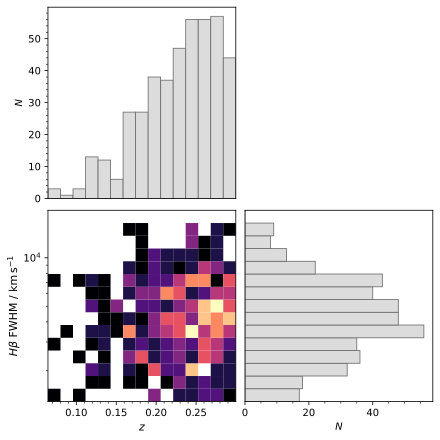

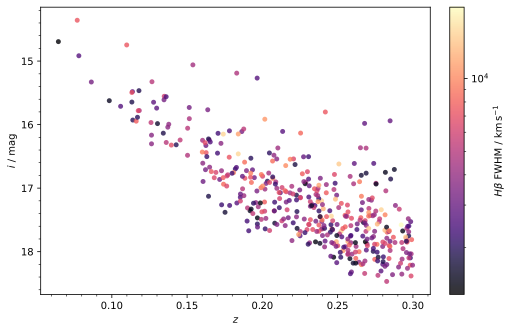

In [8]:
display(data[['z', 'hbeta_flux', 'hbeta_br_fwhm', 'dered_i']].describe()[1:])

fig, axes = gen_corner(
    df=data, 
    x_param='z', 
    y_param='hbeta_br_fwhm',
    x_label='$z$', 
    y_label=r'$H\beta$ FWHM / km$\,$s$^{-1}$',
    bins=15,
    cmap='magma',
    xscale='linear',
    yscale='log')

plt.show()
plt.close()

plt.figure(figsize=[7,4.5])

scatter = plt.scatter(data['z'],
                      data['dered_i'],
                      c=data['hbeta_br_fwhm'],
                      cmap='magma',
                      norm=mpl.colors.LogNorm(),
                      alpha=0.8,
                      edgecolors='none',
                      s=25)

plt.xlabel('$z$')
plt.ylabel('$i$ / mag')

plt.gca().invert_yaxis()

cbar = plt.colorbar(scatter)
cbar.set_label(r'$H\beta$ FWHM / km$\,$s$^{-1}$')

plt.show()
plt.close()

#### b)

#### Required Formulas

$$ $$

*D. W. Hogg (2000)*

$$ $$

- Cosmological Parameter: $$E(z) = \sqrt{\Omega_M (1+z)^3 + \Omega_\Lambda} \qquad\qquad \Omega_K = 0$$

- Comoving Distance: $$D_M = D_C = D_H \int_0^z \frac{dz'}{E(z')} \qquad\qquad D_H = c \, t_H \qquad\qquad t_H = H_0^{-1}$$

- Luminosity Distance: $$D_L = (1 + z)D_M$$

- Specific Luminosity: $$L_{H\beta} = 4\pi D_L^2 S_{H\beta}$$

*Q. Wu (2009)*

$$ $$

- Black Hole Mass: $$M_{BH} = A \left( \frac{L_{H\beta}}{10^{42} \,\text{erg}\,\text{s}^{-1}} \right)^{\! B} \left( \frac{\text{FWHM}_{H\beta}}{10^3 \,\text{km}\,\text{s}^{-1}} \right)^{\! C}\! M_\odot$$ $$\log M_{BH} / M_\odot = A M_R − B$$

- Bolometric Luminosity: $$\log L_\text{BOL} = A \log L_{H\beta} + B$$

- Eddington Luminosity: $$L_\text{EDD} = 4\pi c G M m_P / \sigma_T$$

#### Numerical Calculations

In [9]:
H0 = 67.8
Om = 0.31
Ol = 0.69
c = 299792.458

def get_lum_dist(z, H0=H0, Om=Om, Ol=Ol):
    if z <= 0:
        return 0.0
    z_grid = np.linspace(0, z, 1000)
    E = np.sqrt(Om * (1 + z_grid)**3 + Ol)
    comov_integral = np.trapezoid(1.0 / E, z_grid)

    comov_dist = (c / H0) * comov_integral
    lum_dist = (1 + z) * comov_dist
    return lum_dist

data['lum_dist'] = data['z'].apply(get_lum_dist)

data['hbeta_lum'] = 4 * np.pi * ((data['lum_dist'] * 3.08567758e24)**2) * (data['hbeta_flux'] * 1e-17)

aa, bb, cc = 2.4e6, 5.9e-1, 2e0

data['bhm'] = aa * (data['hbeta_lum'] / 1e42)**bb * (data['hbeta_br_fwhm'] / 1e3)**cc

A, B = 9.4e-1, 5.39e0 

data['bol_lum'] = 10**(A * np.log10(data['hbeta_lum']) + B)

data['edd_lum'] = 1.26e38 * data['bhm']
data['edd_ratio'] = data['bol_lum'] / data['edd_lum']

display(data[['z', 'hbeta_lum', 'bhm', 'bol_lum', 'edd_lum', 'edd_ratio']].describe()[1:])

,z,hbeta_lum,bhm,bol_lum,edd_lum,edd_ratio
mean,0.227720,7.159632e+41,3.890279e+07,5.272788e+44,4.901751e+45,0.246595
std,0.049184,9.013853e+41,4.589149e+07,6.060226e+44,5.782328e+45,0.324389
min,0.064495,2.805250e+40,2.502355e+06,2.576875e+43,3.152967e+44,0.002712
25%,0.196603,2.454061e+41,1.361939e+07,1.979211e+44,1.716043e+45,0.037646
50%,0.237003,4.563560e+41,2.651398e+07,3.546055e+44,3.340761e+45,0.113508
75%,0.266949,8.396097e+41,4.797037e+07,6.289742e+44,6.044267e+45,0.325791
max,0.299768,8.609204e+42,4.428044e+08,5.608739e+45,5.579335e+46,1.874181


,z,hbeta_flux,hbeta_br_fwhm,dered_i
mean,0.227720,536.112046,4888.689461,17.195714
std,0.049184,763.509529,3009.998774,0.734614
min,0.064495,14.087560,1281.100000,14.356970
25%,0.196603,143.941650,2683.150000,16.803050
50%,0.237003,269.876600,4130.200000,17.330940
75%,0.266949,548.574600,6397.950000,17.740765
max,0.299768,6220.282000,19717.100000,18.468790


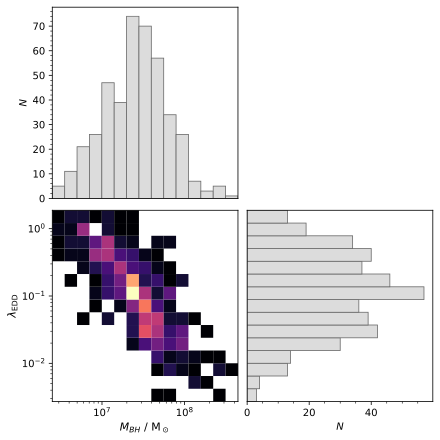

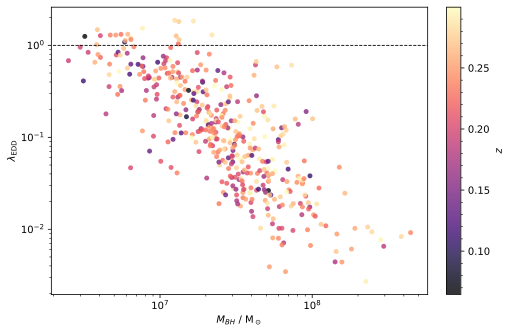

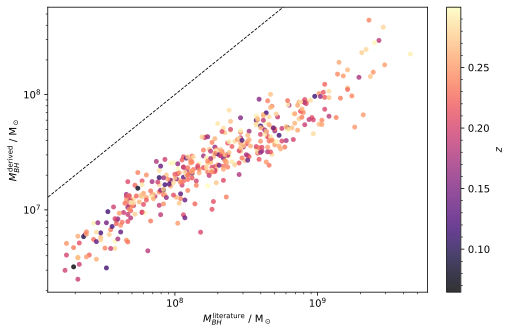

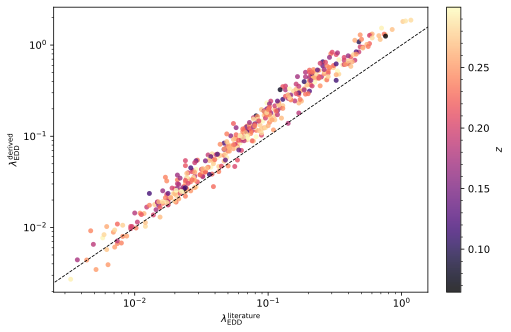


 Mean Absolute Deviations 
Black Hole Mass: 0.856 dex
Eddington Ratio: 0.195 dex


In [10]:
display(data[['z', 'hbeta_flux', 'hbeta_br_fwhm', 'dered_i']].describe()[1:])

fig, axes = gen_corner(
    df=data, 
    x_param='bhm', 
    y_param='edd_ratio',
    x_label=r'$M_{BH}$ / M$_\odot$', 
    y_label=r'$\lambda_\text{EDD}$',
    bins=15,
    cmap='magma',
    xscale='log',
    yscale='log')

plt.show()
plt.close()

plt.figure(figsize=[7,4.5])

scatter = plt.scatter(data['bhm'],
                      data['edd_ratio'],
                      c=data['z'],
                      cmap='magma',
                      alpha=0.8,
                      edgecolors='none',
                      s=25)

plt.xscale('log')
plt.yscale('log')

plt.xlim(plt.xlim())
plt.ylim(plt.ylim())

plt.plot([1e3, 1e13], [1, 1], 'k--', lw=0.85)

plt.xlabel(r'$M_{BH}$ / M$_\odot$')
plt.ylabel(r'$\lambda_\text{EDD}$')

cbar = plt.colorbar(scatter)
cbar.set_label(r'$z$')

plt.show()
plt.close()

plt.figure(figsize=[7,4.5])

scatter = plt.scatter(data['lit_bhm'],
                      data['bhm'],
                      c=data['z'],
                      cmap='magma',
                      alpha=0.8,
                      edgecolors='none',
                      s=25)

plt.xscale('log')
plt.yscale('log')

plt.xlim(plt.xlim())
plt.ylim(plt.ylim())

plt.plot([1e3, 1e13], [1e3, 1e13], 'k--', lw=0.85)

plt.xlabel(r'$M_{BH}^\text{literature}$ / M$_\odot$')
plt.ylabel(r'$M_{BH}^\text{derived}$ / M$_\odot$')

cbar = plt.colorbar(scatter)
cbar.set_label(r'$z$')

plt.show()
plt.close()

plt.figure(figsize=[7,4.5])

scatter = plt.scatter(data['lit_edd_ratio'],
                      data['edd_ratio'],
                      c=data['z'],
                      cmap='magma',
                      alpha=0.8,
                      edgecolors='none',
                      s=25)

plt.xscale('log')
plt.yscale('log')

plt.xlim(plt.xlim())
plt.ylim(plt.ylim())

plt.plot([1e-5, 1e3], [1e-5, 1e3], 'k--', lw=0.85)

plt.xlabel(r'$\lambda_\text{EDD}^\text{literature}$')
plt.ylabel(r'$\lambda_\text{EDD}^\text{derived}$')

cbar = plt.colorbar(scatter)
cbar.set_label(r'$z$')

plt.show()
plt.close()

mad_bhm = np.mean(np.abs(np.log10(data['bhm'] / data['lit_bhm'])))
mad_edd = np.mean(np.abs(np.log10(data['edd_ratio'] / data['lit_edd_ratio'])))

print("\n Mean Absolute Deviations ")
print("==========================")
print(f"Black Hole Mass: {mad_bhm:.3f} dex")
print(f"Eddington Ratio: {mad_edd:.3f} dex")

### 2. Host Galaxy Bulge Luminosity

#### Loading Selection

In [11]:
select = pd.read_table('select.tab')

select[['log_mbh', 'log_edd_ratio']] = 10**select[['log_mbh', 'log_edd_ratio']]

select.columns = ['source', 'z', 'lit_bhm', 'lit_edd_ratio', 'app_mag_r', 'gal_ext_r']

select['lum_dist'] = select['z'].apply(get_lum_dist)

select['redshift_corr'] = -1.25 * np.log10(1 + select['z'])

select.insert(loc=4, column='abs_mag_r', value=(
                                            select['app_mag_r'] 
                                            - 5 * np.log10(select['lum_dist']) 
                                            - 25 
                                            - select['gal_ext_r'] 
                                            - select['redshift_corr']))

select['bhm'] = 10**(-0.5 * select['abs_mag_r'] - 2.74)

display(select)

,source,z,lit_bhm,lit_edd_ratio,abs_mag_r,app_mag_r,gal_ext_r,lum_dist,redshift_corr,bhm
0,3C 48,0.369,6.309573e+08,0.501187,-25.911479,15.555,0.095,2034.214172,-0.170504,1.643386e+10
1,3C 186,1.063,7.943282e+08,0.501187,-26.836233,17.200,0.109,7312.594501,-0.393124,4.765590e+10
2,3C 213.1,0.194,1.258925e+09,0.380189,-21.527480,18.390,0.065,976.668092,-0.096255,1.056185e+08
3,3C 286,0.849,3.162278e+08,0.812831,-26.910723,16.500,0.025,5544.711019,-0.333671,5.192323e+10
4,3C 293,0.045,1.000000e+08,0.016596,-23.168669,13.410,0.036,205.737195,-0.023895,6.987702e+08
5,3C 309.1,0.905,1.258925e+09,0.354813,-27.193029,16.400,0.053,5997.627491,-0.349869,7.186449e+10
6,3C 346,0.162,6.309573e+08,0.002884,-22.851480,16.730,0.147,800.197991,-0.081508,4.849978e+08
7,PKS 1549-79,0.152,1.000000e+08,0.478630,-22.401524,17.330,0.444,746.221929,-0.076816,2.889098e+08
8,PKS 2004-447,0.240,3.981072e+07,0.549541,-22.748321,17.674,0.072,1239.994076,-0.116777,4.306857e+08
9,B1550+5815,1.320,7.943282e+08,0.223872,-28.871438,15.600,0.028,9551.234894,-0.456860,4.962709e+11


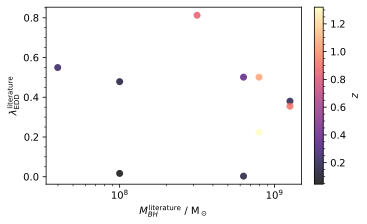

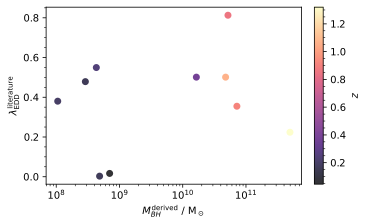

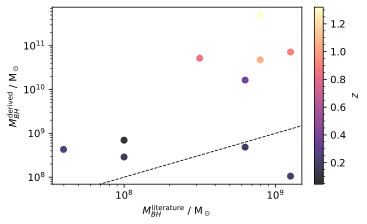


 Mean Absolute Deviations 
Black Hole Mass: 1.349 dex


In [12]:
plt.figure(figsize=[5,3])

scatter = plt.scatter(select['lit_bhm'],
                      select['lit_edd_ratio'],
                      c=select['z'],
                      cmap='magma',
                      alpha=0.8,
                      edgecolors='none',
                      s=50)

plt.xscale('log')

plt.xlabel(r'$M_{BH}^\text{literature}$ / M$_\odot$')
plt.ylabel(r'$\lambda_\text{EDD}^\text{literature}$')

cbar = plt.colorbar(scatter)
cbar.set_label(r'$z$')

plt.show()
plt.close()

plt.figure(figsize=[5,3])

scatter = plt.scatter(select['bhm'],
                      select['lit_edd_ratio'],
                      c=select['z'],
                      cmap='magma',
                      alpha=0.8,
                      edgecolors='none',
                      s=50)

plt.xscale('log')

plt.xlabel(r'$M_{BH}^\text{derived}$ / M$_\odot$')
plt.ylabel(r'$\lambda_\text{EDD}^\text{literature}$')

cbar = plt.colorbar(scatter)
cbar.set_label(r'$z$')

plt.show()
plt.close()

plt.figure(figsize=[5,3])

scatter = plt.scatter(select['lit_bhm'],
                      select['bhm'],
                      c=select['z'],
                      cmap='magma',
                      alpha=0.8,
                      edgecolors='none',
                      s=50)

plt.xscale('log')
plt.yscale('log')

plt.xlim(plt.xlim())
plt.ylim(plt.ylim())

plt.plot([1e3, 1e13], [1e3, 1e13], 'k--', lw=0.85)

plt.xlabel(r'$M_{BH}^\text{literature}$ / M$_\odot$')
plt.ylabel(r'$M_{BH}^\text{derived}$ / M$_\odot$')

cbar = plt.colorbar(scatter)
cbar.set_label(r'$z$')

plt.show()
plt.close()

mad_bhm = np.mean(np.abs(np.log10(select['bhm'] / select['lit_bhm'])))

print("\n Mean Absolute Deviations ")
print("==========================")
print(f"Black Hole Mass: {mad_bhm:.3f} dex")